In [1]:
#!/usr/bin/env python

__title__      = "A Novel Methodology for Modelling First and Second Order Phase Transformations - Thermodynamic Aspects, Variational Methods and Applications"
__author__     = "Wolfgang Flachberger"
__copyright__  = "(c) 2024, Wolfgang Flachberger"
__credits__    = ["Wolfgang Flachberger", "Thomas Antretter"]
__license__    = "GPL"
__version__    = "1.0.1"
__maintainer__ = "Wolfgang Flachberger"
__email__      = "wolfgang.flachberger@gmail.com"
__status__     = "Production"

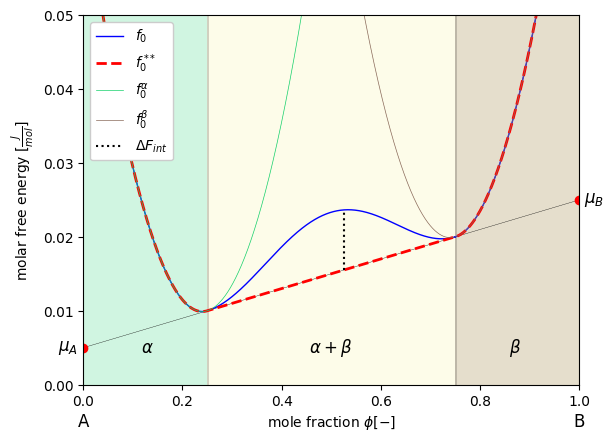

In [2]:
""" + + + + + + + + + + + + + + Utility Functions + + + + + + + + + + + + + + + + """

def magnitude(x): 
    """ magnitude of a scalar """
    return (x**2)**(1/2)

def ramp(x):
    """ ramp function / macaulay bracket """
    return (magnitude(x) + x)/2 

def step(x,a): 
    """ heaviside function with jump at x=a """
    # can be derived by differentiating the ramp function.
    return (-2*a + 2*x)*((-a + x)**2)**(-0.5)/2 + (1.0*a - 1.0*x)*((-a + x)**2)**(-0.5)/2 + 1/2

def h(x,a,b):
    """ smooth transition helper fuction """
    x = (x-a) / (b-a)
    return  3*x**2 - 2*x**3

def smooth_step(x,a,b):
    """ C^2 continous heaviside function with a smooth transition in the intervall [a,b] """
    return (step(x,a) - step(x,b))*h(x,a,b) + step(x,b) 

""" + + + + + + + + + + + + + + Thermodynamics  + + + + + + + + + + + + + + + + + """

def alpha(x):
    """ order function of phase alpha """
    return 1 - smooth_step(x,0.25,0.75)

def beta(x):
    """ order function of phase beta """
    return 1 - alpha(x)

def f_alpha(x): 
    """ free energy of phase alpha """
    return 0.005 + x*0.02 + (x - 0.25)**2

def f_beta(x): 
    """ free energy of phase beta """
    return 0.005 + x*0.02 + (x - 0.75)**2

def f0_(x): 
    """ convex hull over the free energies of alpha and beta """
    return 0.005 + x*0.02 + ramp(x-0.75)**2 + ramp(0.25-x)**2

def f_0(x): 
    """ double-well """
    return f0_(x) + alpha(x)*beta(x)/30

""" + + + + + + + + + + + + + + + + + Plot  + + + + + + + + + + + + + + + + + + + """

import numpy
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

x = numpy.arange(0.0,1.0,0.0001)
#plt.rcParams.update({'font.size': 12})
#plt.rcParams.update({'font.family': 'serif'})
plt.figure(dpi=100)
plt.plot(x, 0.005 + x*0.02,'k', linewidth=0.25)
plt.axvline(x = 0.251,color ='k', linewidth=0.25)
plt.axvline(x = 0.751,color ='k', linewidth=0.25)
plt.plot(x, f_0(x),'b',label=r'${f_0}$', linewidth=1)
plt.plot(x, f0_(x),'r--',label=r'${f_{0}^{\:{**}}}$', linewidth=2)
plt.plot(x, f_alpha(x),'#14d06a',label=r'${f_{0}^{\alpha}}$', linewidth=0.5)
plt.plot(x, f_beta(x),'#896959',label=r'${f_{0}^{\beta}}$', linewidth=0.5)
plt.plot([0.525, 0.525], [0.0155, 0.0235],'k:',label='$\Delta F_{int}$')
plt.xlabel("mole fraction " + r'$\phi[-]$')
plt.ylabel("molar free energy " + r'$[\frac{J}{mol}]$')
plt.xlim([0.0,1.0])
plt.ylim([0.0,0.05])
plt.text(0, -0.005, 'A', ha='center', va='center', fontsize=12)
plt.text(1, -0.005, 'B', ha='center', va='center', fontsize=12)
plt.text(-0.03, 0.005, '$\mu_A$', ha='center', va='center', fontsize=12)
plt.text( 1.03, 0.025, '$\mu_B$', ha='center', va='center', fontsize=12)
plt.text(0.13, 0.005, r'$\alpha$', ha='center', va='center', fontsize=12)
plt.text(0.87, 0.005, r'$\beta$', ha='center', va='center', fontsize=12)
plt.text(0.5 , 0.005, r'$\alpha+\beta$', ha='center', va='center', fontsize=12)
plt.plot(0, 0.005, 'ro')  
plt.plot(1, 0.025, 'ro')
plt.gca().add_patch(Rectangle((0,    0), 0.25, 0.05, alpha=0.2, facecolor='#14d06a'))
plt.gca().add_patch(Rectangle((0.25, 0), 0.75, 0.05, alpha=0.2, facecolor='#f5f293'))
plt.gca().add_patch(Rectangle((0.75, 0), 0.25, 0.05, alpha=0.2, facecolor='#896959'))
plt.legend(loc=2,framealpha=1.0);

In [3]:
! python3 -c 'import dolfinx; print(f"DOLFINx version: {dolfinx.__version__}")'

DOLFINx version: 0.7.2


In [4]:
from mpi4py import MPI
from petsc4py import PETSc
from dolfinx.fem.petsc import NonlinearProblem
from dolfinx.nls.petsc import NewtonSolver
from dolfinx.plot import vtk_mesh
from dolfinx.fem import (FunctionSpace, Function, locate_dofs_topological, 
                         dirichletbc, VectorFunctionSpace, Constant)
from dolfinx.mesh import (create_unit_square, locate_entities, CellType,
                          locate_entities_boundary, create_interval)
from ufl import (TestFunction, TrialFunction, jump, FacetNormal, dx, dS,
                 dot, grad, div, ln, FiniteElement, MixedElement, split,
                 Measure, VectorElement, derivative)
from petsc4py.PETSc import ScalarType
import time
import dolfinx


In [5]:
l   = 1.0 # lenght of domain 
n_e = 200 # number of finite elements

domain = create_interval(MPI.COMM_WORLD, n_e, (0.0, l))

C1 = FunctionSpace(domain, ("CG", 1)) 
C2 = FunctionSpace(domain, ("CG", 2)) 

e_C2 = FiniteElement("CG", domain.ufl_cell(), 2)

W = FunctionSpace(domain, MixedElement([e_C2, e_C2, e_C2]))

w         = Function(W)
(X, j, a) = split(w) 
q         = TestFunction(W)

dt = 1e-3
dx = Measure("dx", metadata={"quadrature_degree": 4}) # degree = 2*int_point-1 (in 1D)

X_0 = Function(C2)
X_0.interpolate(lambda x: x[0]) 

X_n = Function(C2)
X_n.interpolate(X_0) 

X_1 = Function(C1) 
X_1.interpolate(X_0)

initial = numpy.copy(X_1.x.array)

""" + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + """

x = numpy.linspace(0,l,n_e+1)
o = numpy.ones(len(x))


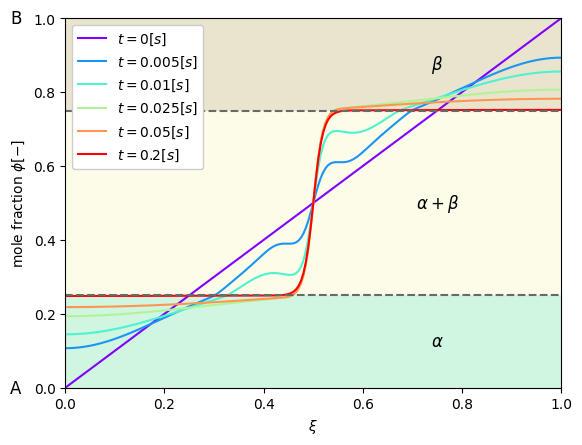

In [6]:
X_n.interpolate(X_0)
    
L  = ( (f_0(X)-f_0(X_n))/dt + dot(j,j)/2 + a*((X-X_n)/dt + j.dx(0)) )*dx 
L += (5e-5/dt)*dot(grad(X),grad(X))*dx

dL = derivative(L,w,q) 

""" + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + """

def on_boundary(x):
    return numpy.full(x.shape[1], True, dtype=bool)

boundary_facets = locate_entities_boundary(domain, domain.topology.dim-1, on_boundary)
boundary_dofs   = locate_dofs_topological(W.sub(1), domain.topology.dim-1, boundary_facets)
bc_0            = dirichletbc(ScalarType(0), boundary_dofs, W.sub(1))

bc = [bc_0]

""" + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + """

problem = NonlinearProblem(dL, w, bc) 
solver  = NewtonSolver(MPI.COMM_WORLD, problem)

t = 0
count = [0,5,10,25,50]
color = iter(plt.cm.rainbow(numpy.linspace(0, 1, len(count)+1)))
for i in range(200):
    
    if i in count:
        X_1.interpolate(X_n)
        plt.plot(x, X_1.x.array, c=next(color), label=r'${t = }$' \
                        +str(numpy.around(t, 3)) \
                        +r'$[s]$')

    solver.solve(w)
    X_n.interpolate(w.sub(0))
    
    t += dt

X_1.interpolate(X_n)
plt.plot(x, X_1.x.array, c=next(color), label=r'${t = }$' \
                        +str(numpy.around(t, 3)) \
                        +r'$[s]$')
plt.plot(x, 0.25*o, color='dimgray', linestyle='dashed')
plt.plot(x, 0.75*o, color='dimgray', linestyle='dashed')
plt.text(-0.1, 0.0, 'A', ha='center', va='center', fontsize=12)
plt.text(-0.1, 1.0, 'B', ha='center', va='center', fontsize=12)
plt.text(0.75, 0.125, r'$\alpha$', ha='center', va='center', fontsize=12)
plt.text(0.75, 0.5, r'$\alpha+\beta$', ha='center', va='center', fontsize=12)
plt.text(0.75, 0.875, r'$\beta$', ha='center', va='center', fontsize=12)
plt.gca().add_patch(Rectangle((0,    0), 1, 0.25, alpha=0.2, facecolor='#14d06a'))
plt.gca().add_patch(Rectangle((0, 0.75), 1, 0.25, alpha=0.2, facecolor='#896959'))
plt.gca().add_patch(Rectangle((0, 0.25), 1, 0.75, alpha=0.2, facecolor='#f5f293'))
plt.xlabel(r"$\xi$") 
plt.ylabel("mole fraction " + r'$\phi [-]$')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.legend(loc=2,framealpha=1.0);

cahnhilliard = numpy.copy(X_1.x.array)


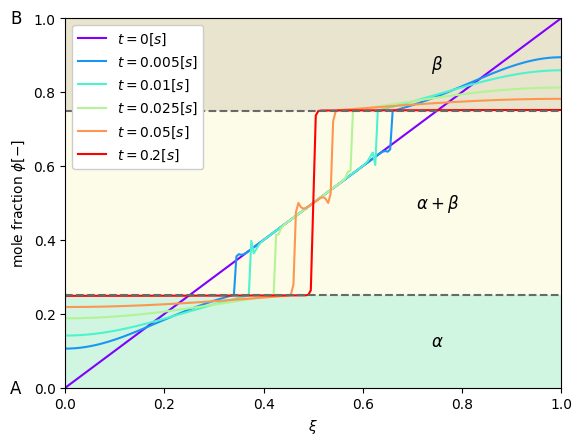

In [7]:
X_n.interpolate(X_0) 

L  = ( (f0_(X)-f0_(X_n))/dt + dot(j,j)/2 + a*((X-X_n)/dt + j.dx(0)) )*dx

dL = derivative(L,w,q)

""" + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + """

problem = NonlinearProblem(dL, w, bc) 
solver  = NewtonSolver(MPI.COMM_WORLD, problem)

t = 0
count = [0,5,10,25,50]
color = iter(plt.cm.rainbow(numpy.linspace(0, 1, len(count)+1)))
for i in range(200):
    
    if i in count:
        X_1.interpolate(X_n)
        plt.plot(x, X_1.x.array, c=next(color), label=r'${t = }$' \
                        +str(numpy.around(t, 3)) \
                        +r'$[s]$')

    solver.solve(w)
    X_n.interpolate(w.sub(0))
    
    t += dt

X_1.interpolate(X_n)
plt.plot(x, X_1.x.array, c=next(color), label=r'${t = }$' \
                        +str(numpy.around(t, 3)) \
                        +r'$[s]$')
plt.plot(x, 0.25*o, color='dimgray', linestyle='dashed')
plt.plot(x, 0.75*o, color='dimgray', linestyle='dashed')
plt.text(-0.1, 0.0, 'A', ha='center', va='center', fontsize=12)
plt.text(-0.1, 1.0, 'B', ha='center', va='center', fontsize=12)
plt.text(0.75, 0.125, r'$\alpha$', ha='center', va='center', fontsize=12)
plt.text(0.75, 0.5, r'$\alpha+\beta$', ha='center', va='center', fontsize=12)
plt.text(0.75, 0.875, r'$\beta$', ha='center', va='center', fontsize=12)
plt.gca().add_patch(Rectangle((0,    0), 1, 0.25, alpha=0.2, facecolor='#14d06a'))
plt.gca().add_patch(Rectangle((0, 0.75), 1, 0.25, alpha=0.2, facecolor='#896959'))
plt.gca().add_patch(Rectangle((0, 0.25), 1, 0.75, alpha=0.2, facecolor='#f5f293'))
plt.xlabel(r"$\xi$")
plt.ylabel("mole fraction " + r'$\phi [-]$')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.legend(loc=2,framealpha=1.0);


limit2 = numpy.copy(X_1.x.array)

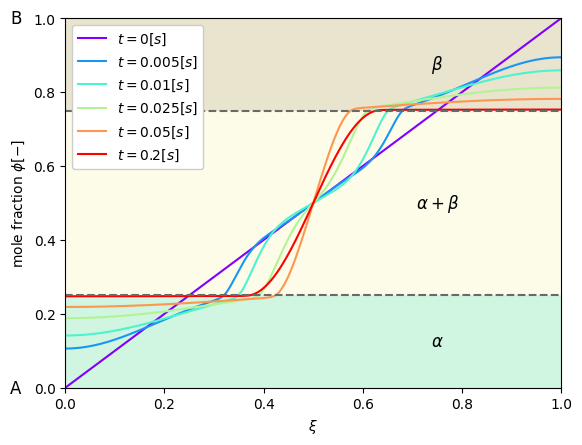

In [8]:
X_n.interpolate(X_0) 

L  = ( (f0_(X)-f0_(X_n))/dt + dot(j,j)/2 + a*((X-X_n)/dt + j.dx(0)) )*dx 
L += (5e-5/dt)*dot(grad(X),grad(X))*dx

dL = derivative(L,w,q)

""" + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + """

problem = NonlinearProblem(dL, w, bc) 
solver  = NewtonSolver(MPI.COMM_WORLD, problem)

t = 0
count = [0,5,10,25,50]
color = iter(plt.cm.rainbow(numpy.linspace(0, 1, len(count)+1)))
for i in range(200):
    
    if i in count:
        X_1.interpolate(X_n)
        plt.plot(x, X_1.x.array, c=next(color), label=r'${t = }$' \
                        +str(numpy.around(t, 3)) \
                        +r'$[s]$')

    solver.solve(w)
    X_n.interpolate(w.sub(0))
    
    t += dt

X_1.interpolate(X_n)
plt.plot(x, X_1.x.array, c=next(color), label=r'${t = }$' \
                        +str(numpy.around(t, 3)) \
                        +r'$[s]$')
plt.plot(x, 0.25*o, color='dimgray', linestyle='dashed')
plt.plot(x, 0.75*o, color='dimgray', linestyle='dashed')
plt.text(-0.1, 0.0, 'A', ha='center', va='center', fontsize=12)
plt.text(-0.1, 1.0, 'B', ha='center', va='center', fontsize=12)
plt.text(0.75, 0.125, r'$\alpha$', ha='center', va='center', fontsize=12)
plt.text(0.75, 0.5, r'$\alpha+\beta$', ha='center', va='center', fontsize=12)
plt.text(0.75, 0.875, r'$\beta$', ha='center', va='center', fontsize=12)
plt.gca().add_patch(Rectangle((0,    0), 1, 0.25, alpha=0.2, facecolor='#14d06a'))
plt.gca().add_patch(Rectangle((0, 0.75), 1, 0.25, alpha=0.2, facecolor='#896959'))
plt.gca().add_patch(Rectangle((0, 0.25), 1, 0.75, alpha=0.2, facecolor='#f5f293'))
plt.xlabel(r"$\xi$")
plt.ylabel("mole fraction " + r'$\phi [-]$')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.legend(loc=2,framealpha=1.0);

limit1 = numpy.copy(X_1.x.array)

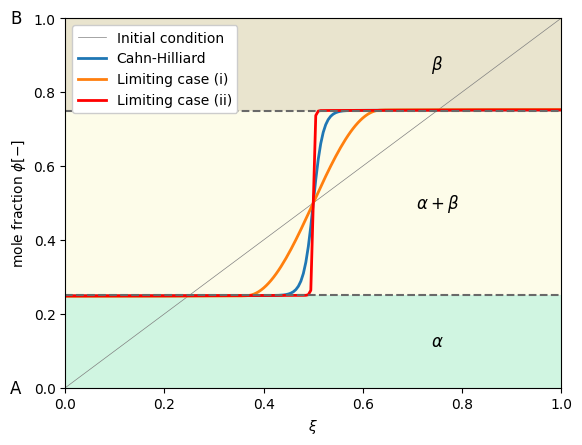

In [9]:
plt.figure(dpi=100)
plt.plot(x, initial,'grey', label='Initial condition', linewidth=0.5)
plt.plot(x, cahnhilliard, label='Cahn-Hilliard', linewidth=2)
plt.plot(x, limit1, label='Limiting case (i)', linewidth=2)
plt.plot(x, limit2, 'r', label='Limiting case (ii)', linewidth=2)
plt.plot(x, 0.25*o, color='dimgray', linestyle='dashed')
plt.plot(x, 0.75*o, color='dimgray', linestyle='dashed')
plt.text(-0.1, 0.0, 'A', ha='center', va='center', fontsize=12)
plt.text(-0.1, 1.0, 'B', ha='center', va='center', fontsize=12)
plt.text(0.75, 0.125, r'$\alpha$', ha='center', va='center', fontsize=12)
plt.text(0.75, 0.5, r'$\alpha+\beta$', ha='center', va='center', fontsize=12)
plt.text(0.75, 0.875, r'$\beta$', ha='center', va='center', fontsize=12)
plt.gca().add_patch(Rectangle((0,    0), 1, 0.25, alpha=0.2, facecolor='#14d06a'))
plt.gca().add_patch(Rectangle((0, 0.75), 1, 0.25, alpha=0.2, facecolor='#896959'))
plt.gca().add_patch(Rectangle((0, 0.25), 1, 0.75, alpha=0.2, facecolor='#f5f293'))
plt.xlabel(r"$\xi$")
plt.ylabel("mole fraction " + r'$\phi [-]$')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.legend(loc=2,framealpha=1.0);

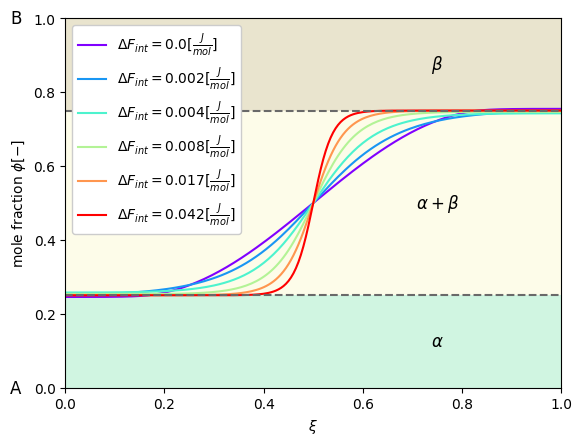

In [10]:
dg_mix = [0.0, 0.25, 0.5, 1, 2, 5]

color = iter(plt.cm.rainbow(numpy.linspace(0, 1, len(dg_mix))))

plt.figure(dpi=100)
for k in range(len(dg_mix)):
    
    def f_0_(x): 
        return f0_(x) + dg_mix[k]*alpha(x)*beta(x)/30
    
    L  = ( (f_0_(X)-f_0_(X_n))/dt + dot(j,j)/2 + a*((X-X_n)/dt + j.dx(0)) )*dx 
    L += (1e-3/dt)*dot(grad(X),grad(X))*dx

    dL = derivative(L,w,q) 

    problem = NonlinearProblem(dL, w, bc) 
    solver  = NewtonSolver(MPI.COMM_WORLD, problem)

    t = 0 

    for i in range(200):

        solver.solve(w)
        X_n.interpolate(w.sub(0))
        t += dt
    
    X_1.interpolate(X_n)
    plt.plot(x, X_1.x.array, c=next(color), label=r'${\Delta F_{int} = }$' \
                                   +str(numpy.around(dg_mix[k]*alpha(0.5)*beta(0.5)/30, 3)) \
                                   +r'$[\frac{J}{mol}]$')

plt.plot(x, 0.25*o, color='dimgray', linestyle='dashed')
plt.plot(x, 0.75*o, color='dimgray', linestyle='dashed')
plt.text(-0.1, 0.0, 'A', ha='center', va='center', fontsize=12)
plt.text(-0.1, 1.0, 'B', ha='center', va='center', fontsize=12)
plt.text(0.75, 0.125, r'$\alpha$', ha='center', va='center', fontsize=12)
plt.text(0.75, 0.5, r'$\alpha+\beta$', ha='center', va='center', fontsize=12)
plt.text(0.75, 0.875, r'$\beta$', ha='center', va='center', fontsize=12)
plt.gca().add_patch(Rectangle((0,    0), 1, 0.25, alpha=0.2, facecolor='#14d06a'))
plt.gca().add_patch(Rectangle((0, 0.75), 1, 0.25, alpha=0.2, facecolor='#896959'))
plt.gca().add_patch(Rectangle((0, 0.25), 1, 0.75, alpha=0.2, facecolor='#f5f293'))
plt.xlabel(r"$\xi$")
plt.ylabel("mole fraction " + r'$\phi [-]$')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.legend(loc=2,framealpha=1.0);

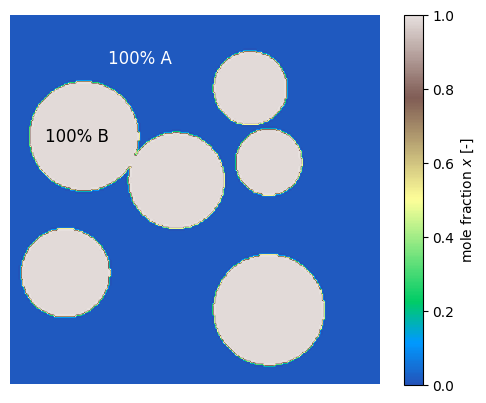

In [11]:
nx = 128

domain = create_unit_square(MPI.COMM_WORLD, nx, nx, CellType.quadrilateral)

order  = 2

S = FunctionSpace(domain, ("CG", order))
V = VectorFunctionSpace(domain, ("CG", order))

s = FiniteElement("CG", domain.ufl_cell(), order)
v = VectorElement("CG", domain.ufl_cell(), order)

W = FunctionSpace(domain, MixedElement([s, v, s]))

w         = Function(W)
(X, j, a) = split(w) 
q         = TestFunction(W)

dt = Constant(domain, 1e-3)
dx = Measure("dx", metadata={"quadrature_degree": 4})
# 1=>1 integrationpoint for quad
# 3=>4 integrationpoints for quad

X_0 = Function(S)
X_0.interpolate(lambda x: 0.01 + 0.98*(((x[0]-0.15)**2+(x[1]-0.3)**2)**0.5 < 0.12) 
                               + 0.98*(((x[0]-0.45)**2+(x[1]-0.55)**2)**0.5 < 0.13) 
                               + 0.98*(((x[0]-0.7)**2+(x[1]-0.2)**2)**0.5 < 0.15)  
                               + 0.98*(((x[0]-0.2)**2+(x[1]-0.67)**2)**0.5 < 0.148) 
                               + 0.98*(((x[0]-0.7)**2+(x[1]-0.6)**2)**0.5 < 0.09) 
                               + 0.98*(((x[0]-0.65)**2+(x[1]-0.8)**2)**0.5 < 0.1))

X_n = Function(S)
X_n.interpolate(X_0)

""" + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + """

def space2pix(pixel, function):
    
    xy_vals = numpy.linspace(0,1,pixel)
    X, Y    = numpy.meshgrid(xy_vals, xy_vals)

    solution = numpy.zeros((pixel,pixel))

    points = []
    for i in range(pixel):
        for j in range(pixel):
            points.append( numpy.array([X[i,j], Y[i,j], 0.0], dtype=domain.geometry.x.dtype) )

    points  = numpy.array(points)
    bb_tree = dolfinx.geometry.bb_tree(domain, domain.topology.dim)

    potential_colliding_cells = dolfinx.geometry.compute_collisions_points(bb_tree, points)
    colliding_cells           = dolfinx.geometry.compute_colliding_cells(domain, potential_colliding_cells, points)

    points_on_proc = []
    cells = []
    for i, point in enumerate(points):
        if len(colliding_cells.links(i)) > 0:
            points_on_proc.append(point)
            cells.append(colliding_cells.links(i)[0])

    points_on_proc = numpy.array(points_on_proc, dtype=numpy.float64).reshape(-1, 3)
    cells = numpy.array(cells, dtype=numpy.int32)
    u_values = function.eval(points_on_proc, cells)

    count = 0 
    for i in range(pixel):
        for j in range(pixel):
            solution[i,j] = u_values[count]
            count += 1 
        
    solution = numpy.flip(solution, axis=0)
    return solution

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(numpy.linspace(minval, maxval, n)))
    return new_cmap


plt.figure(dpi=100)
plt.imshow(space2pix(1080, X_n), vmin=0, vmax=1, interpolation='bilinear', 
            cmap=truncate_colormap(plt.get_cmap('terrain'),0.05,0.95)) # summer jet gnuplot2 terrain_r
plt.colorbar().set_label('mole fraction $\phi$ [-]',size=10)
plt.axis('off')
plt.text(1080*(23/128), 1080*(42/128), "100% B",                ha='center', va='center', fontsize=12)
plt.text(1080*(45/128), 1080*(15/128), "100% A", color='white', ha='center', va='center', fontsize=12)
plt.show()


calculation time: 17.0 [min]


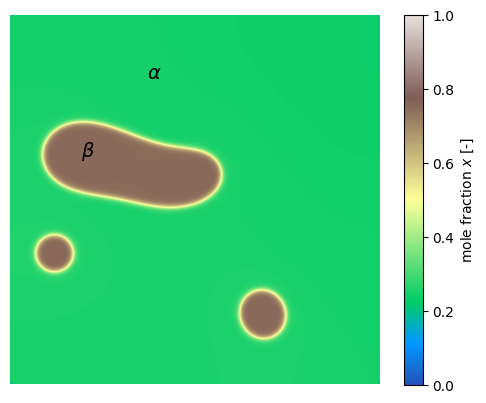

In [12]:
L  = ( (f_0(X)-f_0(X_n))/dt + dot(j,j)/2 + a*((X-X_n)/dt + div(j)) )*dx 
L += (1e-5/dt)*dot(grad(X),grad(X))*dx

dL = derivative(L,w,q)

""" + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + """

def on_boundary(x):
    return numpy.full(x.shape[1], True, dtype=bool)

j_B             = Function(V)
SUB1, _         = W.sub(1).collapse()
boundary_facets = locate_entities_boundary(domain, domain.topology.dim-1, on_boundary)
boundary_dofs_j = locate_dofs_topological((W.sub(1), SUB1), domain.topology.dim-1, boundary_facets)
bc_j            = dirichletbc(j_B, boundary_dofs_j, W.sub(1))
bc              = [bc_j]

""" + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + """

problem = NonlinearProblem(dL, w, bc)
solver  = NewtonSolver(MPI.COMM_WORLD, problem)

#solver.convergence_criterion = "incremental"
#solver.relaxation_parameter = 0.5
#solver.max_it = 100

"""
ksp = solver.krylov_solver
opts = PETSc.Options()
option_prefix = ksp.getOptionsPrefix()
opts[f"{option_prefix}ksp_type"] = "preonly"
opts[f"{option_prefix}pc_type"] = "lu"
opts[f"{option_prefix}pc_factor_mat_solver_type"] = "mumps"
ksp.setFromOptions()
"""

#from dolfinx import log as logs 
#logs.set_log_level(logs.LogLevel.INFO)

t = 0
start = time.perf_counter()
for i in range(100):

    try:
        solver.solve(w)
        X_n.interpolate(w.sub(0))
        t += dt
        
    except: 
        print("breaking...")
        print("iterations:",i)
        break
          
end = time.perf_counter()
print("calculation time:", (end-start)//60,"[min]")

def show(X_n):
    plt.figure(dpi=100)
    plt.imshow(space2pix(1080, X_n), vmin=0, vmax=1, interpolation='bilinear', 
               cmap=truncate_colormap(plt.get_cmap('terrain'),0.05,0.95)) # summer jet gnuplot2 terrain_r
    plt.colorbar().set_label('mole fraction $\phi$ [-]',size=10)
    plt.axis('off')
    plt.text(1080*(27/128), 1080*(47/128), r"$\beta$",  ha='center', va='center', fontsize=14)
    plt.text(1080*(50/128), 1080*(20/128), r"$\alpha$", ha='center', va='center', fontsize=14)
    plt.show()
    
show(X_n)

calculation time: 109.0 [min]


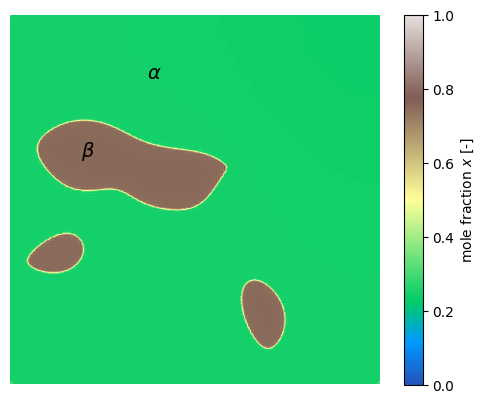

In [13]:
X_n.interpolate(X_0)

L  = ( (f0_(X)-f0_(X_n))/dt + dot(j,j)/2 + a*((X-X_n)/dt + div(j)) )*dx 

dL = derivative(L,w,q)

""" + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + """

problem = NonlinearProblem(dL, w, bc)
solver  = NewtonSolver(MPI.COMM_WORLD, problem)

solver.relaxation_parameter = 0.5
solver.max_it = 100 

t = 0
start = time.perf_counter()
for i in range(100):

    try:
        solver.solve(w)
        X_n.interpolate(w.sub(0))
        t += dt
 
    except: 
        print("breaking...")
        print("iterations:",i)
        break

end = time.perf_counter()
print("calculation time:", (end-start)//60,"[min]")
show(X_n)

calculation time: 100.0 [min]


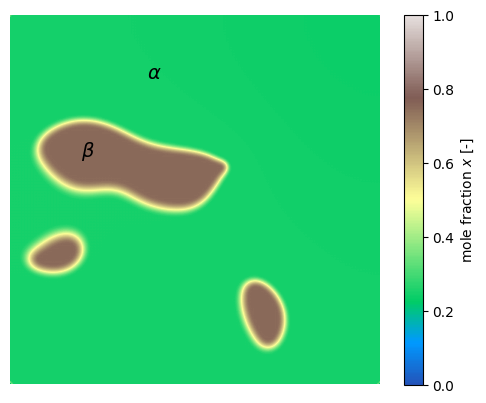

In [14]:
X_n.interpolate(X_0)

L  = ( (f0_(X)-f0_(X_n))/dt + dot(j,j)/2 + a*((X-X_n)/dt + div(j)) )*dx 
L += (1e-7/dt)*dot(grad(X),grad(X))*dx

dL = derivative(L,w,q)

""" + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + """

problem = NonlinearProblem(dL, w, bc)
solver  = NewtonSolver(MPI.COMM_WORLD, problem)

solver.relaxation_parameter = 0.5
solver.max_it = 100 

t = 0
start = time.perf_counter()
for i in range(100):

    try:
        solver.solve(w)
        X_n.interpolate(w.sub(0))
        t += dt
        
    except: 
        print("breaking...")
        print("iterations:",i)
        break

end = time.perf_counter()
print("calculation time:", (end-start)//60,"[min]")
show(X_n)

calculation time: 723.0 [min]


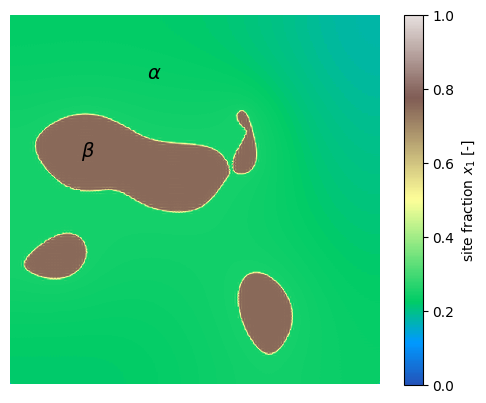

In [17]:

W = FunctionSpace(domain, MixedElement([s, s, v, v, s, s, s]))

w                             = Function(W)
(X0, X1, j0, j1, a0, a1, phi) = split(w) 
q                             = TestFunction(W)

X0_ = Function(S)
X1_ = Function(S) 

X0_.x.array[:] += 1e-3
X1_.interpolate(X_0)

""" + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + """

SUB1, _          = W.sub(2).collapse()
boundary_dofs_j0 = locate_dofs_topological((W.sub(2), SUB1), domain.topology.dim-1, boundary_facets)
bc_j0            = dirichletbc(j_B, boundary_dofs_j0, W.sub(2))

SUB1, _          = W.sub(3).collapse()
boundary_dofs_j1 = locate_dofs_topological((W.sub(3), SUB1), domain.topology.dim-1, boundary_facets)
bc_j1            = dirichletbc(j_B, boundary_dofs_j1, W.sub(3))

bc = [bc_j0, bc_j1]

""" + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + """

def f0(X0, X1): 
    return f0_(X1) + 100*(X0-1e-3)**2

L  = (f0(X0, X1) - f0(X0_, X1_))/dt 
L += dot(j1,j1)/2 + dot(-j0-j1,-j0-j1) + phi**2
L += a1*((X1-X1_)/dt + div(j1) + phi*X1_ ) 
L += a0*((X0-X0_)/dt + div(j0) - phi*(1-X0_)) 
L  = L*dx 

dL = derivative(L,w,q)

""" + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + + """

problem = NonlinearProblem(dL, w, bc)
solver  = NewtonSolver(MPI.COMM_WORLD, problem)

solver.relaxation_parameter = 0.5
solver.max_it = 100 

t = 0
start = time.perf_counter()
for i in range(100):

    try:
        solver.solve(w)
        X0_.interpolate(w.sub(0))
        X1_.interpolate(w.sub(1))
        t += dt
 
    except: 
        print("breaking...")
        print("iterations:",i)
        break

end = time.perf_counter()
print("calculation time:", (end-start)//60,"[min]")

def show(X_n):
    plt.figure(dpi=100)
    plt.imshow(space2pix(1080, X_n), vmin=0, vmax=1, interpolation='none', 
               cmap=truncate_colormap(plt.get_cmap('terrain'),0.05,0.95))
    plt.colorbar().set_label('site fraction $\phi_1$ [-]',size=10)
    plt.axis('off')
    plt.text(1080*(27/128), 1080*(47/128), r"$\beta$",  ha='center', va='center', fontsize=14)
    plt.text(1080*(50/128), 1080*(20/128), r"$\alpha$", ha='center', va='center', fontsize=14)
    plt.show()

show(X1_)

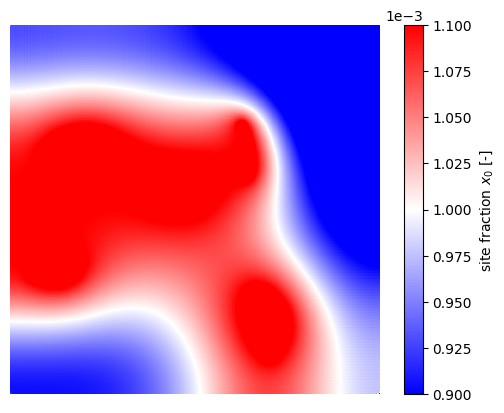

In [18]:
def show(X_n):
    plt.figure(dpi=100)
    plt.imshow(space2pix(1080, X_n), vmin=9e-4, vmax=11e-4, interpolation='none', cmap='bwr')
    cbar = plt.colorbar()
    cbar.formatter.set_powerlimits((0, 0))
    cbar.set_label('site fraction $\phi_0$ [-]', size=10)
    plt.axis('off')
    plt.show()

show(X0_)